### 03. PyTorch Computer Vision

### 0. Computer vision libraries in PyTorch

In [4]:
# Import Pytorch 
# Import the core PyTorch library for machine learning and tensor operations.
import torch 
# Import the neural network module containing building blocks like layers and loss functions.
from torch import nn 

# Import torchvision  
# Import the PyTorch computer vision library for image processing.
import torchvision 
# Import the datasets module to easily download and load standard image datasets.
from torchvision import datasets 
# Import the transform function that converts images into PyTorch tensors.
from torchvision.transforms import ToTensor 

# import matplotlib for visualization 
# Import the plotting framework used to generate charts and display images.
import matplotlib.pyplot as plt 

# Print the active version numbers of the PyTorch and Torchvision libraries.
print(f"Pytorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")


Pytorch version: 2.12.0+cpu
torchvision version: 0.27.0+cpu


### 1. Getting a dataset

In [5]:
# Setup training data
# Define a variable to store the training dataset.
train_data = datasets.FashionMNIST(
    # Specify the local directory folder where the dataset will be stored.
    root="data", # where to download data to?
    # Configure the object to fetch the training split of the dataset.
    train=True, # get training data
    # Enable automatic downloading if the files are missing from the folder.
    download=True, # download data if it doesn't exist on disk
    # Apply a transformation that converts the input images into PyTorch tensors.
    transform=ToTensor(), # images come as PIL format, we want to turn into Torch tensors
    # Keep the original target label formats without applying any extra modifications.
    target_transform=None # you can transform labels as well
# Close the training dataset configuration object.
)
# Setting up test data 
# Define a variable to store the separate evaluation dataset.
test_data = datasets.FashionMNIST(
    # Use the same local directory folder to store the evaluation files.
    root = "data", 
    # Configure the object to fetch the testing split instead of training.
    train= False, 
    # Ensure the testing files download automatically if they are missing.
    download= True , 
    # Convert the testing images into PyTorch tensors for model compatibility.
    transform=ToTensor()
# Close the testing dataset configuration object.
)


In [6]:
len(train_data), len(test_data)

(60000, 10000)

In [7]:
# See the first training example 
image, label = train_data[0]
image, label 


(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [8]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [9]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [10]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [11]:
# Check the shape of our image 
print(f"Image shape: {image.shape} -> [color_channels, height, width]")
print(f"Image label: {class_names[label]}")

Image shape: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Image label: Ankle boot


### 1.2 Visualizing our data

Image shape: torch.Size([1, 28, 28])


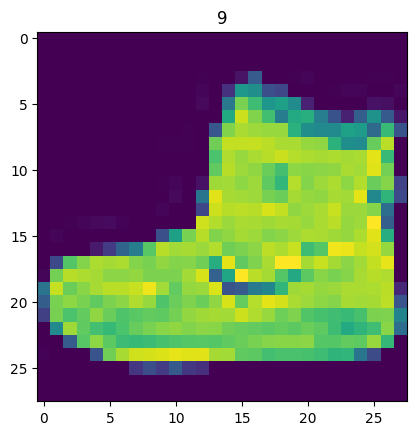

In [12]:
# Import the plotting library to visualize images and charts.
import matplotlib.pyplot as plt 
# Extract the very first image and its numerical label from the training dataset.
image, label = train_data[0]
# Print the dimensions of the image tensor to verify its height, width, and channels.
print(f"Image shape: {image.shape}")
# Remove the extra single-color channel dimension so matplotlib can display the 2D image.
plt.imshow(image.squeeze())
# Display the numerical class label as the title above the plotted image.
plt.title(label);


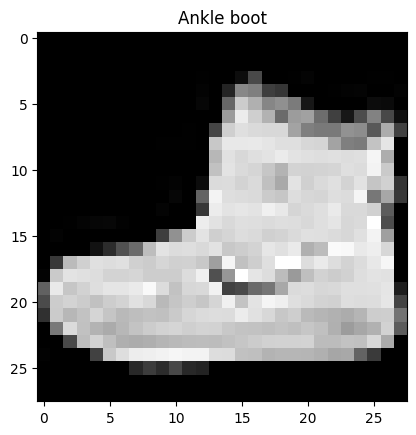

In [13]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label]);

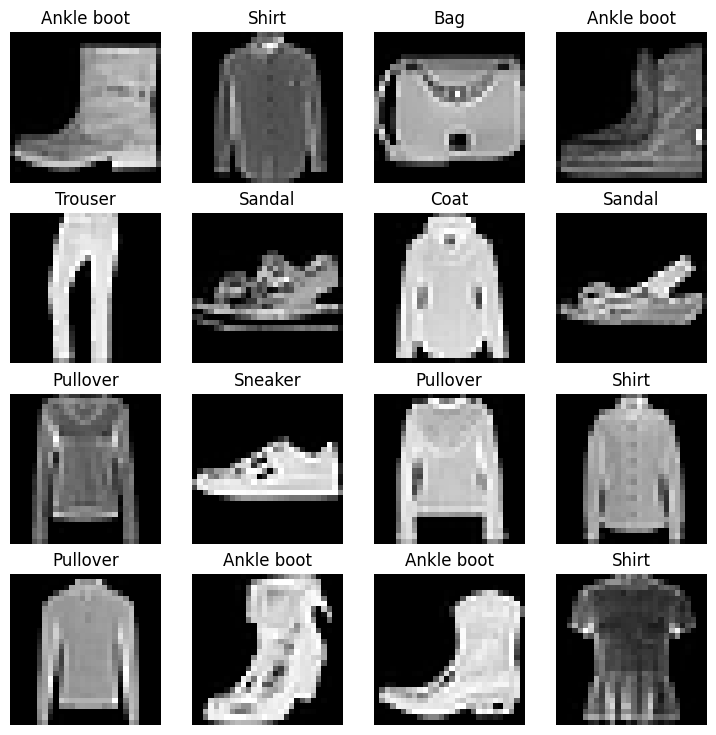

In [14]:
# Plot more images 
# Set a fixed random seed to ensure the random image selection is reproducible.
torch.manual_seed(42)
# Initialize a new matplotlib figure window and set its width and height to 9 inches.
fig = plt.figure(figsize=(9,9))
# Define variables to configure a grid layout with 4 rows and 4 columns.
rows, cols = 4,4 
# Loop through 16 total subplots to populate the grid positions from 1 to 16.
for i in range(1, rows*cols+1):
    # Generate a single random integer index within the range of the training dataset.
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    # Retrieve the random image and its corresponding label index from the dataset.
    img, label = train_data[random_idx]
    # Add a new subplot grid cell at the current position index within the figure layout.
    fig.add_subplot(rows, cols, i)
    # Render the 2D image array onto the subplot utilizing a grayscale color map.
    plt.imshow(img.squeeze(), cmap="gray")
    # Fetch the readable text label string from class_names and display it as the title.
    plt.title(class_names[label])
    # Hide the x-axis and y-axis lines, tick marks, and numerical coordinate labels.
    plt.axis(False);


### 2. Prepare DataLoader

In [ ]:
train_data, test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [15]:
# Import the module used to load dataset splits into small, organized batches.
from torch.utils.data import DataLoader

# Setup the batch size hyperparameter 
# Define a constant storing the number of samples to process at one time.
BATCH_SIZE = 32
# Turn datasets into iterables (batches)
# Create a training loader that groups training data and shuffles it every epoch.
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)

# Create an initial testing data loader to split validation data into batches.
test_dataloader = DataLoader(test_data,
                             # Assign the same standard batch size for evaluation processing.
                             batch_size=BATCH_SIZE,
                             # Keep evaluation data unshuffled to evaluate predictions consistently.
                             shuffle=False)
# Reassign the testing data loader to ensure proper variable initialization.
test_dataloader = DataLoader(test_data,
                             # Map the testing loader to use the defined batch size variable.
                             batch_size=BATCH_SIZE,
                             # Keep the testing dataset sequence in its original static order.
                             shuffle= False)
# Output both initialized iterable data loader objects to confirm their creation.
print(f"DataLoader: {train_dataloader, test_dataloader}")
# Print the total count of training batches generated by dividing the dataset.
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
# Print the total count of evaluation batches generated for model testing.
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")


DataLoader: (<torch.utils.data.dataloader.DataLoader object at 0x0000020D07CBC500>, <torch.utils.data.dataloader.DataLoader object at 0x0000020D07B35A00>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


In [18]:
# Check out what is inside the training dataloader  
train_features_batch, train_labels_batches = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batches.shape 

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
Label: 9, label size: torch.Size([])


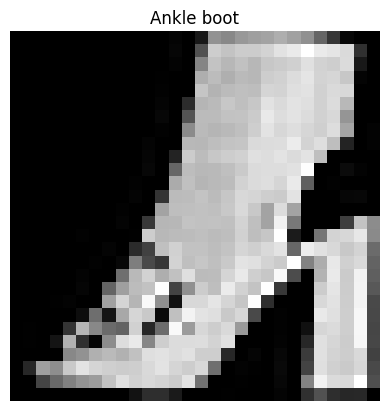

In [20]:
# Show a sample 
# Set a fixed random seed to ensure the random selection is reproducible across runs.
torch.manual_seed(42)
# Generate a random integer index within the range of the current features batch size.
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
# Extract the specific image tensor and its matching label tensor using the random index.
img, label = train_features_batch[random_idx], train_labels_batches[random_idx]
# Display the 2D image matrix using a grayscale color mapping without extra dimensions.
plt.imshow(img.squeeze(), cmap="gray")
# Look up the human-readable class text name matching the target label index value.
plt.title(class_names[label])
# Remove the outer bounding box lines, numerical grid coordinates, and pixel tick marks.
plt.axis("Off");
# Display the dimensions of the selected image tensor to confirm its shape details.
print(f"Image size: {img.shape}")
# Print both the numerical class index value and the shape of the label tensor.
print(f"Label: {label}, label size: {label.shape}")


### 3. Model 0: Build a baseline model

In [21]:
# Create a flatten layer
# Instantiate a PyTorch layer that compresses multidimensional inputs into single-dimension vectors.
flatten_model = nn.Flatten()

# Extract the very first image tensor sample out of the training features batch.
X = train_features_batch[0]

# Pass the single image tensor through the flattening layer to reshape its structure.
output = flatten_model(X)

# Print the original shape dimensions of the input tensor before any reshaping occurs.
print(f"Shape before flattening: {X.shape} -> [color_channels, height, width]")
# Print the final shape dimensions showing the spatial dimensions compressed into one vector.
print(f"Shape after flattening: {output.shape} -> [color_channels, height*width]")


Shape before flattening: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Shape after flattening: torch.Size([1, 784]) -> [color_channels, height*width]


In [22]:
output 

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [23]:
# Import the neural network module from the PyTorch library.
from torch import nn 
# Define a baseline neural network class that inherits from the base model class.
class FashionMNISTModelV0(nn.Module):
    # Initialize the model structure by defining input sizes, hidden sizes, and output sizes.
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        # Call the initialization method of the parent class to set up model tracking.
        super().__init__()
        # Group the model layers into a linear sequence that executes step by step.
        self.layer_stack = nn.Sequential(
            # Unroll the multidimensional input image arrays into single dimensional vectors.
            nn.Flatten(), 
            # Apply a linear matrix multiplication transforming input shapes into hidden dimensions.
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            # Map the hidden features to the final classification count using another linear step.
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        # Close the sequential container layout configuration block.
        )
    # Define the computation path that processes incoming data through the network layers.
    def forward(self,x):
        # Pass the input data tensor directly through the configured sequential layer stack.
        return self.layer_stack(x)


In [24]:
# Set a fixed random seed to guarantee reproducible network initialization and behavior.
torch.manual_seed(42)

# Instantiate the baseline model class using explicit input, hidden, and output sizes.
model_0 = FashionMNISTModelV0(input_shape=784, 
                              # Set the number of internal learning nodes inside the hidden layer.
                              hidden_units=10, 
                              # Set the final output nodes to match the total dataset classes.
                              output_shape=len(class_names)
# Close the arguments list configuration for the model instantiation.
)
# Send the instantiated model weights directly to the central processing unit memory.
model_0.to("cpu")


FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [25]:
dummy_x = torch.rand([1,1,28,28])
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

In [ ]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

### 3.1 Setup loss, optimizer and evaluation metrics

In [28]:
# Set a fixed random seed to guarantee reproducible network initialization and behavior.
torch.manual_seed(42)

# Instantiate the baseline model class using explicit input, hidden, and output sizes.
model_0 = FashionMNISTModelV0(input_shape=784, 
                              # Set the number of internal learning nodes inside the hidden layer.
                              hidden_units=10, 
                              # Set the final output nodes to match the total dataset classes.
                              output_shape=len(class_names)
# Close the arguments list configuration for the model instantiation.
)
# Send the instantiated model weights directly to the central processing unit memory.
model_0.to("cpu")


FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [32]:
# Import the custom accuracy calculation utility function from an external helper file.
from helper_functions import accuracy_fn

# Instantiate the standard categorical cross-entropy loss criterion for multi-class classification problems.
loss_fn = nn.CrossEntropyLoss()
# Initialize a Stochastic Gradient Descent optimization algorithm linked directly to the model parameters.
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)


In [33]:
accuracy_fn

<function helper_functions.accuracy_fn(y_true, y_pred)>

### 3.2 Creating a function to time our experiments

In [34]:
# Import the high-precision clock utility function to measure code execution duration.
from timeit import default_timer as timer 
# Define a function that calculates, prints, and returns the elapsed training time.
def print_train_time(start: float, end: float, device: torch.device= None):
    # Calculate the total elapsed time by finding the difference between timestamps.
    total_time = end - start 
    # Output the calculated duration formatted to three decimal places with device info.
    print(f"Train time one {device}: {total_time:.3f} second")
    # Return the computed duration value back to the main calling script program.
    return total_time


In [ ]:
start_time = timer()
end_time = timer()
print_train_time(start=start_time, end=end_time, device="cpu")

Train time one cpu: 0.000 second


6.10999995842576e-05

### 3.3 Creating a training loop and training a model on batches of data

In [36]:
# Import the smart progress bar library that auto-detects the active console environment.
from tqdm.auto import tqdm

# Set a fixed random seed to ensure reproducible data processing behavior.
torch.manual_seed(42)
# Capture the precise system starting timestamp before initiating the training loops.
train_time_start_on_cpu =  timer()

# Define a constant storing the total passes through the complete dataset.
epochs = 3 

# Loop through the total number of epochs while tracking completion progress.
for epoch in tqdm(range(epochs)): 
    # Print the current epoch iteration block number header to track training.
    print(f"Epoch: {epoch}\n-----")
    # Reset the cumulative loss counter to zero at each epoch start.
    train_loss = 0 
    # Iterate through individual batches extracted sequentially from the data loading object.
    for batch, (X,y) in enumerate(train_dataloader):
        # Set the tracking state of the model explicitly to training configuration.
        model_0.train()
        # Perform the forward computation pass to generate raw prediction logit scores.
        y_pred = model_0(X)

        # Compute the specific difference error value between targets and model predictions.
        loss = loss_fn(y_pred, y)
        # Add the computed batch error cost to the running epoch accumulation.
        train_loss += loss 

        # Clear out any residual parameter gradient history before the new calculation.
        optimizer.zero_grad()
        # Execute the backward propagation pass to calculate fresh tracking weight gradients.
        loss.backward()

        # Update the model weight configuration arrays using the optimization step rules.
        optimizer.step()

        # Check if the current batch index matches the regular progress step.
        if batch % 400 == 0:
            # Print periodic updates detailing the exact quantity of items processed so far.
            print(f"Look at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

# Calculate the mean training error cost across all individual batch steps.
train_loss /= len(train_dataloader)

# Initialize the separate cumulative evaluation metrics counters at baseline zero values.
test_loss, test_acc = 0, 0 
# Transition the model state configuration explicitly to evaluation tracking mode.
model_0.eval()

# Deactivate gradient history tracking to conserve computational overhead and local memory.
with torch.inference_mode():
    # Loop over individual validation data segments stored within the test loader.
    for X, y in test_dataloader:
        # Generate target class prediction vectors for the current validation sample.
        test_pred = model_0(X)
        # Accumulate the calculation error cost for the evaluation dataset samples batch.
        test_loss += loss_fn(test_pred, y)
        # Compute and append the correct classification percentage score for this subset.
        test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))
    # Divide the aggregated evaluation error metrics by the total batch counts.
    test_loss /= len(test_dataloader)
    # Calculate the average prediction accuracy metric over the full testing loop.
    test_acc /= len(test_dataloader)
# Output the final calculated performance metrics summaries to the user screen.
print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

# Capture the exact clock completion timestamp immediately following the computation loops.
train_time_end_on_cpu = timer()
# Compute, display, and log the exact total elapsed code execution time.
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                            # Feed the captured ending stopwatch time value into the function.
                                            end = train_time_end_on_cpu,
                                            # Look up and provide the active host hardware processing unit string.
                                            device=str(next(model_0.parameters()).device))


c:\Users\men_l\Downloads\pytorch\pytorch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-----
Look at 0/60000 samples
Look at 12800/60000 samples
Look at 25600/60000 samples
Look at 38400/60000 samples
Look at 51200/60000 samples


 33%|███▎      | 1/3 [00:09<00:19,  9.90s/it]

Epoch: 1
-----
Look at 0/60000 samples
Look at 12800/60000 samples
Look at 25600/60000 samples
Look at 38400/60000 samples
Look at 51200/60000 samples


 67%|██████▋   | 2/3 [00:18<00:09,  9.04s/it]

Epoch: 2
-----
Look at 0/60000 samples
Look at 12800/60000 samples
Look at 25600/60000 samples
Look at 38400/60000 samples
Look at 51200/60000 samples


100%|██████████| 3/3 [00:27<00:00,  9.05s/it]



Train loss: 0.45325 | Test loss: 0.51088, Test acc: 82.38%

Train time one cpu: 28.385 second


In [38]:
next(model_0.parameters())

Parameter containing:
tensor([[ 0.0273,  0.0298, -0.0068,  ..., -0.0018,  0.0072,  0.0173],
        [-0.0189, -0.0355,  0.0157,  ...,  0.0174,  0.0110,  0.0108],
        [-0.0008,  0.0019,  0.0032,  ...,  0.0121, -0.0118,  0.0077],
        ...,
        [-0.0115,  0.0275, -0.0321,  ...,  0.0541,  0.0470,  0.0010],
        [-0.0231,  0.0252,  0.0238,  ..., -0.0809, -0.0377, -0.0076],
        [ 0.0175, -0.0148,  0.0030,  ..., -0.1108, -0.0660,  0.0111]],
       requires_grad=True)

In [39]:
str(next(model_0.parameters()).device )

'cpu'

### 4. Make predictions and get Model 0 results

In [40]:
# Set a fixed random seed to guarantee reproducible evaluation outcomes across execution runs.
torch.manual_seed(42)
# Define a structured function to evaluate a given model's performance on a specific dataset.
def eval_model(model: torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               accuracy_fn):
    """Returns a dictionary containing the results of model predicting on data_loader.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """
    # Initialize the tracking variables for total loss and accuracy to baseline zero values.
    loss, acc = 0, 0
    # Configure the internal model layers to evaluation mode to deactivate dropout or normalization.
    model.eval()
    # Disable the gradient calculation engine to reduce local memory consumption during runtime testing.
    with torch.inference_mode():
        # Step through every individual batch of input features and ground truth labels sequentially.
        for X, y in data_loader:
            # Make predictions with the model
            # Pass the input batch tensor directly into the model to compute prediction logits.
            y_pred = model(X)
            
            # Accumulate the loss and accuracy values per batch
            # Compute the batch cost difference value and append it to the tracking variable.
            loss += loss_fn(y_pred, y)
            # Find the highest index logit values to determine final predicted classes for accuracy.
            acc += accuracy_fn(y_true=y, 
                               # Feed the predicted label matrix indices directly into the evaluation helper.
                               y_pred=y_pred.argmax(dim=1)) # For accuracy, need the prediction labels (logits -> pred_prob -> pred_labels)
        
        # Scale loss and acc to find the average loss/acc per batch
        # Compute the final average classification error cost value across all data batches.
        loss /= len(data_loader)
        # Compute the final average matching prediction accuracy score over the whole dataset.
        acc /= len(data_loader)
        
    # Construct a structured python key-value data container holding the final execution results.
    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            # Extract the raw numeric scalar value from the tensor object using item.
            "model_loss": loss.item(),
            # Map the calculated accuracy average score value to its respective results key.
            "model_acc": acc}

# Calculate model 0 results on test dataset
# Execute the completed evaluation helper function using the baseline model and test data parameters.
model_0_results = eval_model(model=model_0, data_loader=test_dataloader,
    # Pass the defined loss function and performance metric modules as trailing functional inputs.
    loss_fn=loss_fn, accuracy_fn=accuracy_fn
# Close the parameter configuration block for the model evaluation execution command.
)
# Render the final populated dictionary layout to the notebook output screen.
model_0_results


{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.5108762979507446,
 'model_acc': 82.37819488817891}

### 5. Setup device agnostic-code (for using a GPU if there is one)

In [41]:
!nvidia-smi

Sat May 16 18:09:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.97                 Driver Version: 555.97         CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2060      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   53C    P8             14W /   85W |       0MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [42]:
import torch 
device = "cuda" if torch.cuda.is_available() else "cpu"
device 

'cpu'

### 6. Model 1: Building a better model with non-linearity

In [43]:
# Define an upgraded neural network class that introduces non-linear activation functions.
class FashionMNISTModelV1(nn.Module):
    # Initialize the network dimensions by setting the input size, hidden units, and output size.
    def __init__(self, input_shape: int, hidden_units:int, output_shape: int):
        # Trigger the parent class constructor method to register the new model structure.
        super().__init__()
        # Sequence the network layers inside a container to process structural transformations.
        self.layer_stack = nn.Sequential(
            # Flatten multi-dimensional input image matrices into single-dimensional feature arrays.
            nn.Flatten(), 
            # Apply an initial linear transformation to map input nodes to hidden dimensions.
            nn.Linear(in_features=input_shape, out_features=hidden_units), 
            # Apply a Rectified Linear Unit function to introduce non-linearity after the linear step.
            nn.ReLU(), 
            # Map the hidden node features to the final total target classification dimensions.
            nn.Linear(in_features=hidden_units, out_features=output_shape),
            # Add a final non-linear activation step before returning structural raw outputs.
            nn.ReLU()
        # Close the configuration block of the sequential layers container.
        )
    # Define the custom pipeline that moves feature data batches forward through the model.
    def forward(self, x: torch.Tensor):
        # Push the raw input tensor through the sequential collection of network layers.
        return self.layer_stack(x)


In [44]:
next(model_0.parameters()).device

device(type='cpu')

In [45]:
device 

'cpu'

In [51]:
# Set a fixed random seed to guarantee reproducible layer initialization and weight values.
torch.manual_seed(42)
# Instantiate the non-linear model and immediately send its weights to the target computing device.
model_1 = FashionMNISTModelV1(input_shape=784,
                              # Configure the number of internal learning nodes for the hidden layer blocks.
                              hidden_units=10, 
                              # Match the final output dimensions to the total count of dataset classes.
                              output_shape=len(class_names)).to(device)
# Retrieve and display the active hardware processing device where the model weights reside.
next(model_1.parameters()).device


device(type='cpu')

### 6.1 Setup loss, optimizer and evaluation metrics

In [50]:
# Import the custom classification accuracy metric calculator from your local utilities module.
from helper_functions import accuracy_fn 
# Instantiate the default categorical cross-entropy loss tracking object for multi-class targets.
loss_fn = nn.CrossEntropyLoss()
# Initialize a Stochastic Gradient Descent optimizer bound directly to the new model parameters.
optimizer = torch.optim.SGD(params=model_1.parameters(),lr =0.1)


### 6.2 Functionizing training and test loops

In [52]:
# Define a modular function to handle the training operations for a single full epoch.
def train_step(model: torch.nn.Module,
               # Accept an iterable data loader object containing batched training features and labels.
               data_loader: torch.utils.data.DataLoader,
               # Accept the tracking criterion function used to compute performance prediction error.
               loss_fn: torch.nn.Module,
               # Accept the parameter optimization algorithm object to update network learning weights.
               optimizer: torch.optim.Optimizer,
               # Accept a specific helper metric function to calculate prediction accuracy scores.
               accuracy_fn,
               # Assign a default target hardware computing destination variable for tensor placement.
               device: torch.device = device):
    # Initialize running accumulator counters for training loss and accuracy at baseline zero.
    train_loss, train_acc = 0, 0
    # Transfer the full internal model network parameters to the active target processing hardware.
    model.to(device)

    # Loop sequentially through indexed batches of data pulled from the active training loader.
    for batch, (X,y) in enumerate(data_loader): 
        # Explicitly move the current feature images and target labels to the active device memory.
        X, y = X.to(device), y.to(device)

        # Run a forward computation pass to generate raw model class prediction logit values.
        y_pred = model(X)

        # Calculate the direct loss discrepancy score between the predictions and target truths.
        loss = loss_fn(y_pred, y)
        # Append the calculated single-batch loss score to the overall epoch loss tracker.
        train_loss += loss 
        # Calculate and accumulate the exact prediction accuracy percentage score for this subset.
        train_acc += accuracy_fn(y_true=y, 
                                 # Convert logits into absolute class prediction indices via argmax.
                                 y_pred = y_pred.argmax(dim=1))
        
        # Reset any leftover tracking weight gradients back to zero before calculating new updates.
        optimizer.zero_grad()

        # Run backpropagation calculations to generate parameter updates across the active layers.
        loss.backward()

        # Apply the optimization update rules to modify and improve the active model parameters.
        optimizer.step()

    # Calculate the average training loss across all processed individual dataset loader batches.
    train_loss /= len(data_loader)
    # Calculate the average training accuracy across all processed individual dataset loader batches.
    train_acc /= len(data_loader)
    # Print the aggregated average training step loss and accuracy scores out to the screen.
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

# Define a modular evaluation function to handle the testing operations over validation datasets.
def test_step(data_loader: torch.utils.data.DataLoader,
              # Accept the target neural network model instance to verify classification capabilities.
              model: torch.nn.Module, 
              # Accept the loss criterion structure used to determine tracking prediction error.
              loss_fn : torch.nn.Module, 
              # Accept the standard scoring function to determine correct classification ratios.
              accuracy_fn, 
              # Assign a default target hardware processing unit variable for data tensor routing.
              device: torch.device= device):
    # Initialize running evaluation performance metrics accumulators at structural zero baselines.
    test_loss, test_acc = 0,0
    # Transfer the structural model parameter tensors directly to the target execution hardware.
    model.to(device)
    # Configure the internal layer states to evaluation mode to lock specific tracking layers.
    model.eval()

    # Disable the tracking gradient engine to optimize calculation performance and conserve local memory.
    with torch.inference_mode():
        # Iterate sequentially through the input features and true target labels within the loader.
        for X, y in data_loader:
            # Shift the active evaluation images and labels over to the active computing hardware.
            X, y = X.to(device), y.to(device)

            # Pass the input batch values through the network to calculate prediction class logits.
            test_pred = model(X)

            # Compute and aggregate the validation batch error loss value to the tracker variable.
            test_loss += loss_fn(test_pred, y)
            # Compute and add the correct classification percentage score for this testing subset.
            test_acc += accuracy_fn(y_true=y, 
                                    # Convert the prediction vector logits into a clean scalar target class index.
                                    y_pred = test_pred.argmax(dim=1))

        # Determine the definitive average testing dataset loss across all evaluation batches.
        test_loss /= len(data_loader) 
        # Determine the definitive average testing dataset accuracy across all evaluation batches.
        test_acc /= len(data_loader)
        # Print the final aggregated performance metric scores for the validation check.
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")


In [53]:
# Define a modular function to handle the training operations for a single full epoch.
def train_step(model: torch.nn.Module,
               # Accept an iterable data loader object containing batched training features and labels.
               data_loader: torch.utils.data.DataLoader,
               # Accept the tracking criterion function used to compute performance prediction error.
               loss_fn: torch.nn.Module,
               # Accept the parameter optimization algorithm object to update network learning weights.
               optimizer: torch.optim.Optimizer,
               # Accept a specific helper metric function to calculate prediction accuracy scores.
               accuracy_fn,
               # Assign a default target hardware computing destination variable for tensor placement.
               device: torch.device = device):
    # Initialize running accumulator counters for training loss and accuracy at baseline zero.
    train_loss, train_acc = 0, 0
    # Transfer the full internal model network parameters to the active target processing hardware.
    model.to(device)

    # Loop sequentially through indexed batches of data pulled from the active training loader.
    for batch, (X,y) in enumerate(data_loader): 
        # Explicitly move the current feature images and target labels to the active device memory.
        X, y = X.to(device), y.to(device)

        # Run a forward computation pass to generate raw model class prediction logit values.
        y_pred = model(X)

        # Calculate the direct loss discrepancy score between the predictions and target truths.
        loss = loss_fn(y_pred, y)
        # Append the calculated single-batch loss score to the overall epoch loss tracker.
        train_loss += loss 
        # Calculate and accumulate the exact prediction accuracy percentage score for this subset.
        train_acc += accuracy_fn(y_true=y, 
                                 # Convert logits into absolute class prediction indices via argmax.
                                 y_pred = y_pred.argmax(dim=1))
        
        # Reset any leftover tracking weight gradients back to zero before calculating new updates.
        optimizer.zero_grad()

        # Run backpropagation calculations to generate parameter updates across the active layers.
        loss.backward()

        # Apply the optimization update rules to modify and improve the active model parameters.
        optimizer.step()

    # Calculate the average training loss across all processed individual dataset loader batches.
    train_loss /= len(data_loader)
    # Calculate the average training accuracy across all processed individual dataset loader batches.
    train_acc /= len(data_loader)
    # Print the aggregated average training step loss and accuracy scores out to the screen.
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

# Define a modular evaluation function to handle the testing operations over validation datasets.
def test_step(data_loader: torch.utils.data.DataLoader,
              # Accept the target neural network model instance to verify classification capabilities.
              model: torch.nn.Module, 
              # Accept the loss criterion structure used to determine tracking prediction error.
              loss_fn : torch.nn.Module, 
              # Accept the standard scoring function to determine correct classification ratios.
              accuracy_fn, 
              # Assign a default target hardware processing unit variable for data tensor routing.
              device: torch.device= device):
    # Initialize running evaluation performance metrics accumulators at structural zero baselines.
    test_loss, test_acc = 0,0
    # Transfer the structural model parameter tensors directly to the target execution hardware.
    model.to(device)
    # Configure the internal layer states to evaluation mode to lock specific tracking layers.
    model.eval()

    # Disable the tracking gradient engine to optimize calculation performance and conserve local memory.
    with torch.inference_mode():
        # Iterate sequentially through the input features and true target labels within the loader.
        for X, y in data_loader:
            # Shift the active evaluation images and labels over to the active computing hardware.
            X, y = X.to(device), y.to(device)

            # Pass the input batch values through the network to calculate prediction class logits.
            test_pred = model(X)

            # Compute and aggregate the validation batch error loss value to the tracker variable.
            test_loss += loss_fn(test_pred, y)
            # Compute and add the correct classification percentage score for this testing subset.
            test_acc += accuracy_fn(y_true=y, 
                                    # Convert the prediction vector logits into a clean scalar target class index.
                                    y_pred = test_pred.argmax(dim=1))

        # Determine the definitive average testing dataset loss across all evaluation batches.
        test_loss /= len(data_loader) 
        # Determine the definitive average testing dataset accuracy across all evaluation batches.
        test_acc /= len(data_loader)
        # Print the final aggregated performance metric scores for the validation check.
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")


In [54]:
total_train_time_model_0

28.385164799999984

In [57]:
# Set a fixed random seed to guarantee reproducible data processing and batch shuffling.
torch.manual_seed(42)

# Measure time
# Import the precise system clock utility to track exactly how long the training process takes.
from timeit import default_timer as timer
# Capture the initial stopwatch timestamp right before entering the training loop blocks.
train_time_start_on_gpu = timer()

# Define the hyperparameter for the total number of complete passes through the dataset.
epochs = 3
# Iterate through each epoch sequentially while rendering a clean visual progress bar.
for epoch in tqdm(range(epochs)):
    # Output a clear separator header to distinctively mark the start of the current epoch.
    print(f"Epoch: {epoch}\n---------")
    # Execute the custom training step function to update model weights across training batches.
    train_step(data_loader=train_dataloader, 
        # Pass your non-linear neural network model instance to optimize its tracking parameters.
        model=model_1, 
        # Provide the categorical cross-entropy loss tracking criterion to measure batch errors.
        loss_fn=loss_fn,
        # Supply the specific Stochastic Gradient Descent optimizer algorithm instance to apply updates.
        optimizer=optimizer,
        # Pass the accuracy calculation helper function to measure batch training performance.
        accuracy_fn=accuracy_fn
    # Close the argument parameter block for the modular training step execution command.
    )
    # Execute the custom validation step function to evaluate performance on unseen data.
    test_step(data_loader=test_dataloader,
        # Pass the same non-linear model instance to verify current generalization capability.
        model=model_1,
        # Use the matching cross-entropy loss function to calculate validation error rates.
        loss_fn=loss_fn,
        # Provide the standard accuracy scorer function to determine correct test classifications.
        accuracy_fn=accuracy_fn
    # Close the argument parameter block for the modular testing step execution command.
    )

# Capture the final system stopwatch timestamp immediately after finishing all loops.
train_time_end_on_gpu = timer()
# Compute, display, and return the total duration spent processing the full training pipeline.
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            # Feed the captured post-training stopwatch time value into the calculation.
                                            end=train_time_end_on_gpu,
                                            # Pass the active hardware destination string to display processing unit details.
                                            device=device)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 2.30166 | Train accuracy: 11.31%


 33%|███▎      | 1/3 [00:10<00:20, 10.48s/it]

Test loss: 2.30211 | Test accuracy: 10.75%

Epoch: 1
---------
Train loss: 2.30166 | Train accuracy: 11.31%


 67%|██████▋   | 2/3 [00:20<00:10, 10.32s/it]

Test loss: 2.30211 | Test accuracy: 10.75%

Epoch: 2
---------
Train loss: 2.30166 | Train accuracy: 11.31%


100%|██████████| 3/3 [00:31<00:00, 10.41s/it]

Test loss: 2.30211 | Test accuracy: 10.75%

Train time one cpu: 31.230 second


In [58]:
torch.manual_seed(42)

model_1_results = eval_model(model= model_1,
                             data_loader=test_dataloader, 
                             loss_fn=loss_fn, 
                             accuracy_fn=accuracy_fn)
model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 2.3021068572998047,
 'model_acc': 10.75279552715655}

In [59]:
# Move values to device
# Set a fixed random seed to guarantee reproducible evaluation outcomes across execution runs.
torch.manual_seed(42)
# Define a structured function to evaluate a given model's performance on a target device.
def eval_model(model: torch.nn.Module, 
               # Accept an iterable data loader object containing batched verification features and labels.
               data_loader: torch.utils.data.DataLoader, 
               # Accept the tracking criterion function used to compute performance prediction error.
               loss_fn: torch.nn.Module, 
               # Accept a specific helper metric function to calculate prediction accuracy scores.
               accuracy_fn, 
               # Assign a default target hardware computing destination variable for tensor placement.
               device: torch.device = device):
    """Evaluates a given model on a given dataset.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.
        device (str, optional): Target device to compute on. Defaults to device.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """
    # Initialize the tracking variables for total loss and accuracy to baseline zero values.
    loss, acc = 0, 0
    # Configure the internal model layers to evaluation mode to deactivate dropout or normalization.
    model.eval()
    # Disable the gradient calculation engine to reduce local memory consumption during runtime testing.
    with torch.inference_mode():
        # Step through every individual batch of input features and ground truth labels sequentially.
        for X, y in data_loader:
            # Send data to the target device
            # Explicitly move the current feature images and target labels to the active device memory.
            X, y = X.to(device), y.to(device)
            # Pass the device-aligned feature tensor into the model to compute prediction logits.
            y_pred = model(X)
            # Compute the batch cost difference value and append it to the tracking variable.
            loss += loss_fn(y_pred, y)
            # Find the highest index logit values to determine final predicted classes for accuracy.
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
        
        # Scale loss and acc
        # Compute the final average classification error cost value across all data batches.
        loss /= len(data_loader)
        # Compute the final average matching prediction accuracy score over the whole dataset.
        acc /= len(data_loader)
    # Construct a structured python key-value data container holding the final execution results.
    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            # Extract the raw numeric scalar value from the tensor object using item.
            "model_loss": loss.item(),
            # Map the calculated accuracy average score value to its respective results key.
            "model_acc": acc}


In [60]:
# Calculate model 1 results with device-agnostic code 
model_1_results = eval_model(model=model_1, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn,
    device=device
)
model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 2.3021068572998047,
 'model_acc': 10.75279552715655}

In [61]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.5108762979507446,
 'model_acc': 82.37819488817891}

### 7. Model 2: Building a Convolutional Neural Network (CNN)

In [62]:
# Define a convolutional neural network class based on the TinyVGG architectural layout.
class FashionMNISTModelV2(nn.Module):

    # Initialize the structural configuration blocks, layer parameters, and internal channel sizes.
    def __init__ (self, input_shape: int, hidden_units: int, output_shape: int): 
        # Invoke the base module constructor method to correctly register layer tracking states.
        super().__init__()
        # Assemble the first sequential extraction block containing convolution and pooling layers.
        self.block_1 = nn.Sequential(
            # Apply a 2D convolution to extract local spatial features from raw image channels.
            nn.Conv2d(in_channels= input_shape, 
                      # Configure the quantity of output feature maps generated by this step.
                      out_channels= hidden_units, 
                      # Set a three-by-three pixel window dimension for the sliding filter matrix.
                      kernel_size= 3, 
                      # Slide the convolutional filter forward across the image one pixel at a time.
                      stride= 1 , 
                      # Add a border edge of one pixel to preserve the original spatial dimensions.
                      padding=1), 
            # Apply a Rectified Linear Unit activation to incorporate non-linear processing features.
            nn.ReLU(), 
            # Apply another 2D convolution to deeper process the extracted feature map tensor arrays.
            nn.Conv2d(in_channels=hidden_units, 
                      # Keep the channel count constant to maintain consistency across this block.
                      out_channels=hidden_units, 
                      # Keep the sliding window filter size at identical three-by-three dimensions.
                      kernel_size= 3, 
                      # Move the tracking window filter incrementally across the layer by single units.
                      stride=1, 
                      # Pad the tensor bounds symmetrically with zeros to match width and height profiles.
                      padding=1), 
            # Apply a secondary Rectified Linear Unit activation step to the feature map results.
            nn.ReLU(),
            # Reduce spatial width and height dimensions by half by selecting maximum pixel values.
            nn.MaxPool2d(kernel_size=2, stride=2)
        # Close the configuration block container layout for the initial extraction sequence.
        )
        # Assemble the secondary feature extraction pipeline utilizing matching structural dimensions.
        self.block_2 = nn.Sequential(
            # Extract higher-level abstraction mappings through a secondary 2D convolution step.
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            # Introduce non-linear behavior features into the second block pipeline computation path.
            nn.ReLU(), 
            # Implement a trailing convolution layer inside the feature processing stage block.
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1), 
            # Run the output feature array maps through a secondary localized activation check.
            nn.ReLU(), 
            # Downsample the feature maps again using a standard two-by-two window step dimension.
            nn.MaxPool2d(2)
        # Close the configuration container layout block for the second feature pipeline.
        )
        # Define the terminal classification layer stack to calculate target class output logits.
        self.classifier = nn.Sequential(
            # Flatten the remaining spatial multi-dimensional tensor features into a flat array vector.
            nn.Flatten(), 
            # Map the flattened spatial features directly to the target dataset output dimensions.
            nn.Linear(in_features=hidden_units*7*7, 
                      # Map the output nodes to equal the total unique data classification categories.
                      out_features=output_shape)
        # Close the trailing classification layers sequential block configuration interface code.
        )
    # Define the computational feedforward graph pipeline structure for incoming image tensors.
    def forward(self, x: torch.Tensor):
        # Process the input data tensor through the initial feature extraction layer sequence.
        x = self.block_1(x)
        # Feed the generated feature tensor arrays through the secondary downsampling block sequence.
        x = self.block_2(x)
        # Pass the extracted feature vectors through the terminal linear classification layer layout.
        x = self.classifier(x)
        # Return the final calculated raw category classification prediction logit values matrix.
        return x 

# Establish a fixed random seed to guarantee reproducible model parameter weight initializations.
torch.manual_seed(42)
# Instantiate the completed convolutional network model and transfer it to the target hardware device.
model_2 = FashionMNISTModelV2(input_shape=1,
                              # Configure the quantity of internal feature tracking channel units.
                              hidden_units=10, 
                              # Map the final output array nodes to match the dataset class list count.
                              output_shape=len(class_names)).to(device)
# Print the full network architectural design layer hierarchy out onto the user screen interface.
model_2


FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [63]:
image.shape

torch.Size([1, 28, 28])

### 7.1 Stepping through nn.Conv2d()

In [64]:
torch.manual_seed(42)
images = torch.randn(size=(32, 3, 64, 64))
test_image = images[0]
print(f"Image batch shape: {images.shape}")
print(f"Single Image Shape: {test_image.shape}")
print(f"Single image pixel values: \n{test_image}")

Image batch shape: torch.Size([32, 3, 64, 64])
Single Image Shape: torch.Size([3, 64, 64])
Single image pixel values: 
tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]]

In [70]:
torch.manual_seed(42)
conv_layer = nn.Conv2d(in_channels=3, 
                       out_channels=10, 
                       kernel_size=3, 
                       stride=1, 
                       padding=0)
conv_layer(test_image)

tensor([[[ 1.5396,  0.0516,  0.6454,  ..., -0.3673,  0.8711,  0.4256],
         [ 0.3662,  1.0114, -0.5997,  ...,  0.8983,  0.2809, -0.2741],
         [ 1.2664, -1.4054,  0.3727,  ..., -0.3409,  1.2191, -0.0463],
         ...,
         [-0.1541,  0.5132, -0.3624,  ..., -0.2360, -0.4609, -0.0035],
         [ 0.2981, -0.2432,  1.5012,  ..., -0.6289, -0.7283, -0.5767],
         [-0.0386, -0.0781, -0.0388,  ...,  0.2842,  0.4228, -0.1802]],

        [[-0.2840, -0.0319, -0.4455,  ..., -0.7956,  1.5599, -1.2449],
         [ 0.2753, -0.1262, -0.6541,  ..., -0.2211,  0.1999, -0.8856],
         [-0.5404, -1.5489,  0.0249,  ..., -0.5932, -1.0913, -0.3849],
         ...,
         [ 0.3870, -0.4064, -0.8236,  ...,  0.1734, -0.4330, -0.4951],
         [-0.1984, -0.6386,  1.0263,  ..., -0.9401, -0.0585, -0.7833],
         [-0.6306, -0.2052, -0.3694,  ..., -1.3248,  0.2456, -0.7134]],

        [[ 0.4414,  0.5100,  0.4846,  ..., -0.8484,  0.2638,  1.1258],
         [ 0.8117,  0.3191, -0.0157,  ...,  1

In [65]:
test_image.shape 

torch.Size([3, 64, 64])

In [66]:
test_image.unsqueeze(dim=0).shape 

torch.Size([1, 3, 64, 64])

In [71]:
conv_layer(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 62, 62])

In [72]:
torch.manual_seed(42)
# Create a new conv_layer with different values (try setting these to whatever you like)
conv_layer_2 = nn.Conv2d(in_channels=3, # same number of color channels as our input image
                         out_channels=10,
                         kernel_size=(5, 5), # kernel is usually a square so a tuple also works
                         stride=2,
                         padding=0)

# Pass single image through new conv_layer_2 (this calls nn.Conv2d()'s forward() method on the input)
conv_layer_2(test_image.unsqueeze(dim=0)).shape

torch.Size([1, 10, 30, 30])

In [73]:
print(conv_layer_2.state_dict())

OrderedDict({'weight': tensor([[[[ 0.0883,  0.0958, -0.0271,  0.1061, -0.0253],
          [ 0.0233, -0.0562,  0.0678,  0.1018, -0.0847],
          [ 0.1004,  0.0216,  0.0853,  0.0156,  0.0557],
          [-0.0163,  0.0890,  0.0171, -0.0539,  0.0294],
          [-0.0532, -0.0135, -0.0469,  0.0766, -0.0911]],

         [[-0.0532, -0.0326, -0.0694,  0.0109, -0.1140],
          [ 0.1043, -0.0981,  0.0891,  0.0192, -0.0375],
          [ 0.0714,  0.0180,  0.0933,  0.0126, -0.0364],
          [ 0.0310, -0.0313,  0.0486,  0.1031,  0.0667],
          [-0.0505,  0.0667,  0.0207,  0.0586, -0.0704]],

         [[-0.1143, -0.0446, -0.0886,  0.0947,  0.0333],
          [ 0.0478,  0.0365, -0.0020,  0.0904, -0.0820],
          [ 0.0073, -0.0788,  0.0356, -0.0398,  0.0354],
          [-0.0241,  0.0958, -0.0684, -0.0689, -0.0689],
          [ 0.1039,  0.0385,  0.1111, -0.0953, -0.1145]]],


        [[[-0.0903, -0.0777,  0.0468,  0.0413,  0.0959],
          [-0.0596, -0.0787,  0.0613, -0.0467,  0.0701],


In [74]:
print(f"conv_layer_2 weight shape: \n{conv_layer_2.weight.shape} -> [out_channels=10, in_channels=3, kernel_size=5, kernel_size=5]")
print(f"\nconv_layer_2 bias shape: \n{conv_layer_2.bias.shape} -> [out_channels=10]")

conv_layer_2 weight shape: 
torch.Size([10, 3, 5, 5]) -> [out_channels=10, in_channels=3, kernel_size=5, kernel_size=5]

conv_layer_2 bias shape: 
torch.Size([10]) -> [out_channels=10]


### 7.2 Stepping through nn.MaxPool2d()

In [75]:
test_image.shape 

torch.Size([3, 64, 64])

In [76]:
print(f"Test image original shape: {test_image.shape}")
print(f"Test image with unsqueezed dimension: {test_image.unsqueeze(dim=0).shape}")

max_pool_player = nn.MaxPool2d(kernel_size=2)
test_image_through_conv = conv_layer(test_image.unsqueeze(dim=0))
print(f"Shape after going through conv_layer(): {test_image_through_conv.shape}")

test_image_through_conv_and_max_pool = max_pool_player(test_image_through_conv)
print(f"Shape after going through conv_layer() and max_pool__layer(): {test_image_through_conv.shape}")

Test image original shape: torch.Size([3, 64, 64])
Test image with unsqueezed dimension: torch.Size([1, 3, 64, 64])
Shape after going through conv_layer(): torch.Size([1, 10, 62, 62])
Shape after going through conv_layer() and max_pool__layer(): torch.Size([1, 10, 62, 62])


In [77]:
torch.manual_seed(42)
random_tensor = torch.randn(size=(1,1,2,2))
print(f"Random tensor: {random_tensor}")
print(f"Random tensor shape: {random_tensor.shape}")

max_pool_layer = nn.MaxPool2d(kernel_size=2)

max_pool_tensor = max_pool_layer(random_tensor)
print(f"\nMax pool tensor: \n {max_pool_tensor} <- this is the the maximum value from random_tensor")
print(f"Max pool tensor shape: {max_pool_tensor.shape}")

Random tensor: tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])
Random tensor shape: torch.Size([1, 1, 2, 2])

Max pool tensor: 
 tensor([[[[0.3367]]]]) <- this is the the maximum value from random_tensor
Max pool tensor shape: torch.Size([1, 1, 1, 1])


In [78]:
rand_image_tensor = torch.randn(size=(1,28,28))
rand_image_tensor.shape 

torch.Size([1, 28, 28])

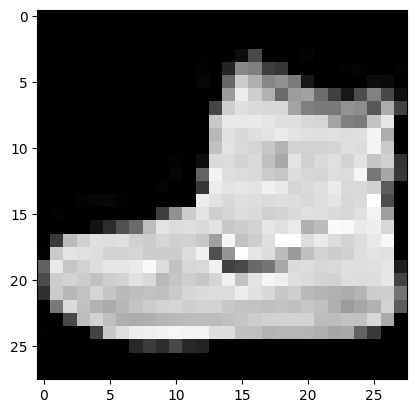

In [79]:
plt.imshow(image.squeeze(), cmap="gray")

In [80]:
# Pass image through model 
model_2(rand_image_tensor.unsqueeze(0).to(device))

tensor([[ 0.0424, -0.0839,  0.0839, -0.0463,  0.0053,  0.0437,  0.0025,  0.0108,
         -0.0158, -0.0177]], grad_fn=<AddmmBackward0>)

### 7.3 Setup a loss function and optimizer for model_2

In [81]:
# Setup loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(), 
                             lr=0.1)

In [82]:
model_2.state_dict()

OrderedDict([('block_1.0.weight',
              tensor([[[[ 0.2548,  0.2767, -0.0781],
                        [ 0.3062, -0.0730,  0.0673],
                        [-0.1623,  0.1958,  0.2938]]],
              
              
                      [[[-0.2445,  0.2897,  0.0624],
                        [ 0.2463,  0.0451,  0.1607],
                        [-0.0471,  0.2570,  0.0493]]],
              
              
                      [[[-0.1556,  0.0850, -0.1536],
                        [-0.0391, -0.1354,  0.2211],
                        [-0.2631, -0.1537, -0.0941]]],
              
              
                      [[[-0.2004,  0.0315, -0.3292],
                        [ 0.3010, -0.2832,  0.2573],
                        [ 0.0555, -0.1082,  0.2060]]],
              
              
                      [[[ 0.0520,  0.2693,  0.0364],
                        [-0.1051,  0.0896, -0.0904],
                        [ 0.1403,  0.2976,  0.1927]]],
              
              
           

### 7.4 Training and testing model_2 using our training and test functions

In [83]:
# Set a fixed random seed to guarantee reproducible data processing and batch shuffling.
torch.manual_seed(42)

# Measure time
# Import the precise system clock utility to track exactly how long the training process takes.
from timeit import default_timer as timer
# Capture the initial stopwatch timestamp right before entering the training loop blocks.
train_time_start_model_2 = timer()

# Train and test model 
# Define the hyperparameter for the total number of complete passes through the dataset.
epochs = 3
# Iterate through each epoch sequentially while rendering a clean visual progress bar.
for epoch in tqdm(range(epochs)):
    # Output a clear separator header to distinctively mark the start of the current epoch.
    print(f"Epoch: {epoch}\n---------")
    # Execute the custom training step function to update model weights across training batches.
    train_step(data_loader=train_dataloader, 
        # Pass your advanced convolutional neural network model instance to optimize its weights.
        model=model_2, 
        # Provide the categorical cross-entropy loss tracking criterion to measure batch errors.
        loss_fn=loss_fn,
        # Supply the specific Stochastic Gradient Descent optimizer algorithm instance to apply updates.
        optimizer=optimizer,
        # Pass the accuracy calculation helper function to measure batch training performance.
        accuracy_fn=accuracy_fn,
        # Explicitly pass the active hardware processing destination for data tensor operations.
        device=device
    # Close the argument parameter block for the modular training step execution command.
    )
    # Execute the custom validation step function to evaluate performance on unseen data.
    test_step(data_loader=test_dataloader,
        # Pass the same convolutional model instance to verify current generalization capability.
        model=model_2,
        # Use the matching cross-entropy loss function to calculate validation error rates.
        loss_fn=loss_fn,
        # Provide the standard accuracy scorer function to determine correct test classifications.
        accuracy_fn=accuracy_fn,
        # Explicitly pass the target hardware execution device for evaluation operations.
        device=device
    # Close the argument parameter block for the modular testing step execution command.
    )

# Capture the final system stopwatch timestamp immediately after finishing all loops.
train_time_end_model_2 = timer()
# Compute, display, and return the total duration spent processing the full training pipeline.
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                           # Feed the captured post-training stopwatch time value into the calculation.
                                           end=train_time_end_model_2,
                                           # Pass the active hardware destination string to display processing unit details.
                                           device=device)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.58803 | Train accuracy: 78.66%


 33%|███▎      | 1/3 [00:24<00:49, 24.74s/it]

Test loss: 0.39328 | Test accuracy: 85.85%

Epoch: 1
---------
Train loss: 0.36233 | Train accuracy: 86.91%


 67%|██████▋   | 2/3 [00:47<00:23, 23.69s/it]

Test loss: 0.34791 | Test accuracy: 87.06%

Epoch: 2
---------
Train loss: 0.32423 | Train accuracy: 88.24%


100%|██████████| 3/3 [01:13<00:00, 24.66s/it]

Test loss: 0.32136 | Test accuracy: 88.18%

Train time one cpu: 73.994 second


In [84]:
# Explicitly move the final trained convolutional neural network model parameters to the target computing hardware.
model_2 = model_2.to(device)
# Execute the modular evaluation helper function to compute final performance statistics on the testing split.
model_2_results = eval_model(
    # Pass the active convolutional model instance to analyze its classification capabilities.
    model=model_2,
    # Provide the verification data loading object containing the unseen test dataset batches.
    data_loader=test_dataloader,
    # Supply the standard categorical cross-entropy loss tracking criterion to measure prediction errors.
    loss_fn=loss_fn,
    # Pass the matching accuracy evaluation function to compute definitive prediction scoring ratios.
    accuracy_fn=accuracy_fn,
    # Specify the target execution device destination to route evaluation data tensors properly.
    device=device
)

# Output the populated evaluation results dictionary onto the notebook interface screen.
model_2_results


{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32135605812072754,
 'model_acc': 88.17891373801918}

In [85]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.5108762979507446,
 'model_acc': 82.37819488817891}

### 8. Compare model results and training time

In [87]:
import pandas as pd 
compare_results = pd.DataFrame([model_0_results, model_1_results, model_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.510876,82.378195
1,FashionMNISTModelV1,2.302107,10.752796
2,FashionMNISTModelV2,0.321356,88.178914


In [88]:
compare_results["training_time"] = [model_0_results, model_1_results, model_2_results]
compare_results

,model_name,model_loss,model_acc,training_time
0,FashionMNISTModelV0,0.510876,82.378195,"{'model_name': 'FashionMNISTModelV0', 'model_l..."
1,FashionMNISTModelV1,2.302107,10.752796,"{'model_name': 'FashionMNISTModelV1', 'model_l..."
2,FashionMNISTModelV2,0.321356,88.178914,"{'model_name': 'FashionMNISTModelV2', 'model_l..."


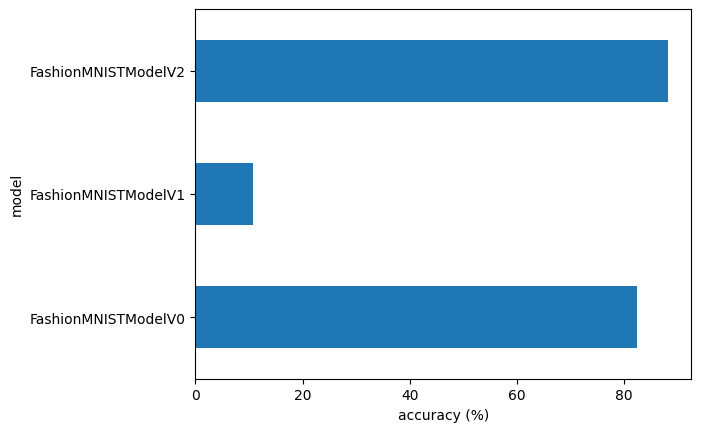

In [89]:
# Visualize our model results 
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model");

### 9. Make and evaluate random predictions with best model

In [90]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # Prepare sample
            sample = torch.unsqueeze(sample, dim=0).to(device) # Add an extra dimension and send sample to device

            # Forward pass (model outputs raw logit)
            pred_logit = model(sample)

            # Get prediction probability (logit -> prediction probability)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 1, so can perform on dim=0)

            # Get pred_prob off GPU for further calculations
            pred_probs.append(pred_prob.cpu())
            
    # Stack the pred_probs to turn list into a tensor
    return torch.stack(pred_probs)

In [91]:
img, label = test_data[0][:10]
img.shape, label 

(torch.Size([1, 28, 28]), 9)

In [92]:
# Import the standard Python library used to handle random data generation and sampling.
import random 
# Set a static random seed value to ensure that the selection of test samples is reproducible.
random.seed(42)
# Initialize an empty list container to store the randomly selected image tensors.
test_samples = []
# Initialize an empty list container to store the true labels matching the chosen images.
test_labels = []
# Convert the dataset object into a flat list and randomly extract nine sample pairs.
for sample, label in random.sample(list(test_data),k=9):
    # Append the extracted single image tensor sample onto the end of the tracking list.
    test_samples.append(sample)
    # Append the extracted numerical target label index onto the end of the tracking list.
    test_labels.append(label)
# Print out the explicit tensor dimension profile and class details for the first sample.
print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({class_names[test_labels[0]]})")


Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 5 (Sandal)


Text(0.5, 1.0, 'Sandal')

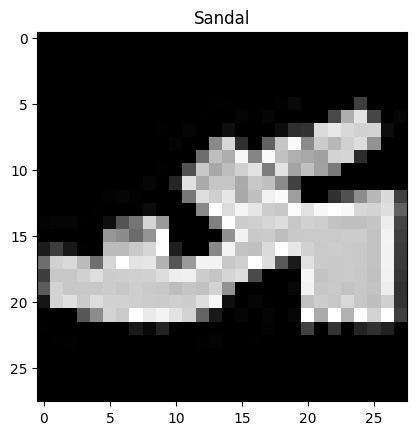

In [93]:
plt.imshow(test_samples[0].squeeze(), cmap="gray")
plt.title(class_names[test_labels[0]])

In [95]:
# Make predictions on test samples with model 2
pred_probs = make_predictions(model=model_2, data=test_samples)
pred_probs[:2]

tensor([[7.2156e-08, 6.3010e-08, 8.3812e-08, 3.8142e-07, 4.2571e-08, 9.9986e-01,
         2.6169e-07, 2.2250e-05, 1.8396e-05, 9.4379e-05],
        [1.7710e-02, 6.9064e-01, 3.4791e-04, 1.6542e-01, 6.5489e-02, 4.1298e-05,
         5.9148e-02, 1.3950e-04, 7.5191e-04, 3.1446e-04]])

In [96]:
test_labels

[5, 1, 7, 4, 3, 0, 4, 7, 1]

In [97]:
# Turn the prediction probabilities into prediction labels by taking the argmax()
pred_classes = pred_probs.argmax(dim=1)
pred_classes 

tensor([5, 1, 7, 4, 3, 0, 4, 7, 1])

In [98]:
# Are our predictions in the same form as our test labels? 
test_labels, pred_classes

([5, 1, 7, 4, 3, 0, 4, 7, 1], tensor([5, 1, 7, 4, 3, 0, 4, 7, 1]))

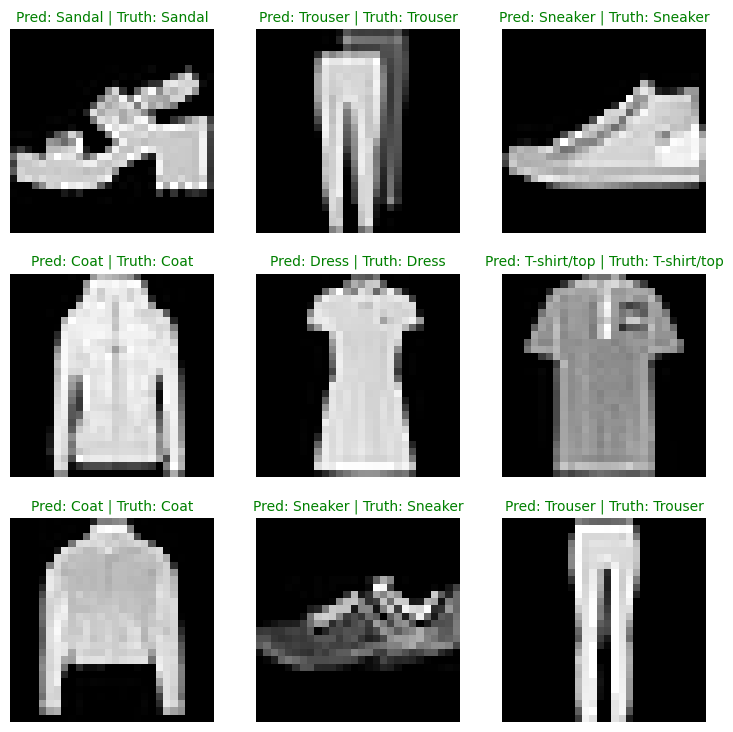

In [99]:
# Plot predictions
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  # Create a subplot
  plt.subplot(nrows, ncols, i+1)

  # Plot the target image
  plt.imshow(sample.squeeze(), cmap="gray")

  # Find the prediction label (in text form, e.g. "Sandal")
  pred_label = class_names[pred_classes[i]]

  # Get the truth label (in text form, e.g. "T-shirt")
  truth_label = class_names[test_labels[i]] 

  # Create the title text of the plot
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"
  
  # Check for equality and change title colour accordingly
  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g") # green text if correct
  else:
      plt.title(title_text, fontsize=10, c="r") # red text if wrong
  plt.axis(False);

### 10. Making a confusion matrix for further prediction evaluation

In [100]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# 1. Make predictions with trained model
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    # Send data and targets to target device
    X, y = X.to(device), y.to(device)
    # Do the forward pass
    y_logit = model_2(X)
    # Turn predictions   from logits -> prediction probabilities -> predictions labels
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 32, so can perform on dim=1)
    # Put predictions on CPU for evaluation
    y_preds.append(y_pred.cpu())
# Concatenate list of predictions into a tensor
y_pred_tensor = torch.cat(y_preds)
y_pred_tensor

Making predictions: 100%|██████████| 313/313 [00:02<00:00, 137.05it/s]


tensor([9, 2, 1,  ..., 8, 1, 8])

In [101]:
len(y_pred_tensor)

10000

In [102]:
# Import the standard system library to interact with the runtime environment variables.
import sys

# Initiate a monitored execution block to handle imports and verify package dependencies.
try:
    # Attempt to import the evaluation metrics tracking library into the local namespace.
    import torchmetrics
    # Attempt to import the machine learning extensions library for data plotting tasks.
    import mlxtend
    # Output the currently active library version sequence string for the extensions package.
    print(f"mlxtend version: {mlxtend.__version__}")
    # Force a condition check ensuring the current minor version meets the performance minimum.
    assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend version should be 0.19.0 or higher"

# Capture any dependency failures or version verification errors during execution.
except Exception as e:
    # Print an information notice indicating that missing external dependencies are being downloaded.
    print("Installing torchmetrics and mlxtend...")
    # Execute the package manager inline command to download and upgrade both required libraries.
    %pip install torchmetrics mlxtend --upgrade

    # Re-attempt importing the metrics compilation toolkit into the environment after installation.
    import torchmetrics
    # Re-attempt importing the specialized data extension plotting utilities package.
    import mlxtend
    # Output the fresh package framework version sequence string to confirm a successful installation.
    print(f"mlxtend version: {mlxtend.__version__}")


Installing torchmetrics and mlxtend...
  Using cached torchmetrics-1.9.0-py3-none-any.whl.metadata (23 kB)
  Using cached mlxtend-0.24.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached lightning_utilities-0.15.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached torchmetrics-1.9.0-py3-none-any.whl (983 kB)
Using cached mlxtend-0.24.0-py3-none-any.whl (1.4 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached lightning_utilities-0.15.3-py3-none-any.whl (31 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl (8.0 MB)
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ---------------------------------

In [103]:
import mlxtend 
print(mlxtend.__version__)
assert int(mlxtend.__version__.split(".")[1]) >= 19

0.24.0


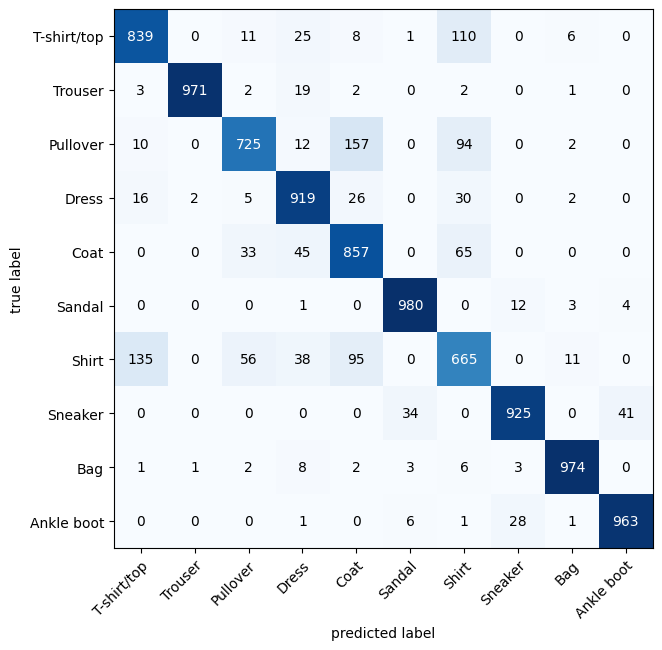

In [106]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor, 
                  target=test_data.targets)

fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7)
)


In [107]:
confmat_tensor

tensor([[839,   0,  11,  25,   8,   1, 110,   0,   6,   0],
        [  3, 971,   2,  19,   2,   0,   2,   0,   1,   0],
        [ 10,   0, 725,  12, 157,   0,  94,   0,   2,   0],
        [ 16,   2,   5, 919,  26,   0,  30,   0,   2,   0],
        [  0,   0,  33,  45, 857,   0,  65,   0,   0,   0],
        [  0,   0,   0,   1,   0, 980,   0,  12,   3,   4],
        [135,   0,  56,  38,  95,   0, 665,   0,  11,   0],
        [  0,   0,   0,   0,   0,  34,   0, 925,   0,  41],
        [  1,   1,   2,   8,   2,   3,   6,   3, 974,   0],
        [  0,   0,   0,   1,   0,   6,   1,  28,   1, 963]])

### 11. Save and load best performing model

In [108]:
# Import the object-oriented filesystem path utility module from the standard library.
from pathlib import Path 
# Instantiate a targeted path configuration object pointing to a local directory folder.
MODEL_PATH = Path("models")
# Create the physical directory on your storage drive including any missing parent folders.
MODEL_PATH.mkdir(parents=True, 
                # Avoid throwing an execution error if the targeted directory layout already exists.
                exist_ok= True)
# Define the designated file string name for the target serialization save destination.
MODEL_NAME = "03_pytorch_computer_vision_model_2.pth"
# Combine the base folder path and targeted file name into a definitive target path destination.
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME 

# Print out the final file system destination path to confirm where files are writing.
print(f"Saving model to : {MODEL_SAVE_PATH}")
# Serialize and write the trained network weight parameters into local persistent hardware storage.
torch.save(obj=model_2.state_dict(), 
           # Assign the active filesystem output destination layout path for file storage.
           f=MODEL_SAVE_PATH)


Saving model to : models\03_pytorch_computer_vision_model_2.pth


In [109]:
model_2.state_dict()

OrderedDict([('block_1.0.weight',
              tensor([[[[ 0.3103,  0.3059, -0.4159],
                        [ 0.1756,  0.2118,  0.0071],
                        [-0.4702,  0.0051,  0.5083]]],
              
              
                      [[[-0.3930,  0.3913, -0.1545],
                        [ 0.2805,  0.4511,  0.1045],
                        [-0.1159,  0.4221,  0.0741]]],
              
              
                      [[[-0.3496, -0.1507, -0.0131],
                        [-0.5964, -0.6334,  0.1794],
                        [-0.7270, -0.6199, -0.1162]]],
              
              
                      [[[-0.7418, -0.9644, -0.7892],
                        [ 0.2244, -0.7924,  0.0495],
                        [ 0.3185,  0.0084,  0.4159]]],
              
              
                      [[[-0.1140,  0.2366, -0.2773],
                        [-0.2487,  0.1999, -0.4686],
                        [-0.0890,  0.2596,  0.0226]]],
              
              
           

In [110]:
image_shape = [1,28,28]

In [111]:
loaded_model_2 = FashionMNISTModelV2(input_shape=1, 
                                     hidden_units=10,
                                     output_shape=10)

loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

loaded_model_2 = loaded_model_2.to(device)

In [112]:
torch.manual_seed(42)
loaded_model_2_results = eval_model(
    model = loaded_model_2, 
    data_loader = test_dataloader,
    loss_fn = loss_fn, 
    accuracy_fn = accuracy_fn     
)

loaded_model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32135605812072754,
 'model_acc': 88.17891373801918}

In [113]:
model_2_results 

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32135605812072754,
 'model_acc': 88.17891373801918}

In [114]:
torch.isclose(torch.tensor(model_2_results["model_loss"]),
              torch.tensor(loaded_model_2_results["model_loss"]),
              atol=1e-08,
              rtol = 0.0001)

tensor(True)